100%|██████████| 2/2 [00:00<00:00, 12483.05it/s]


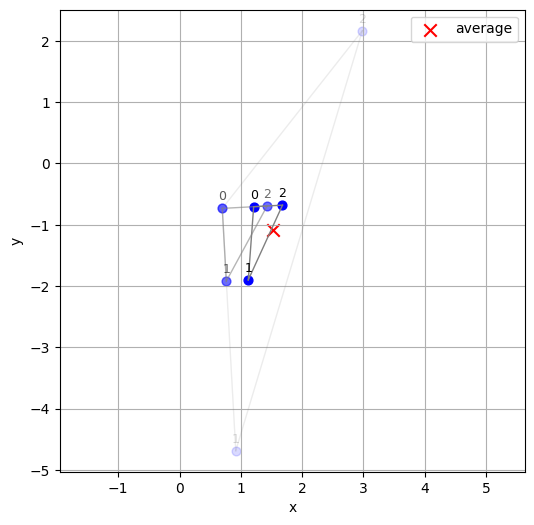

100%|██████████| 2/2 [00:00<00:00, 21290.88it/s]


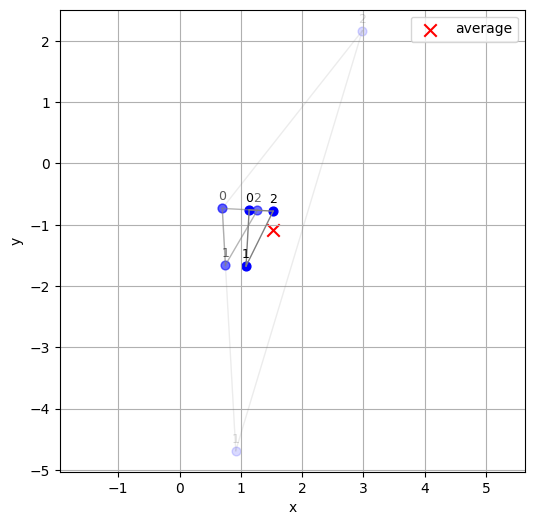

100%|██████████| 2/2 [00:00<00:00, 23237.14it/s]


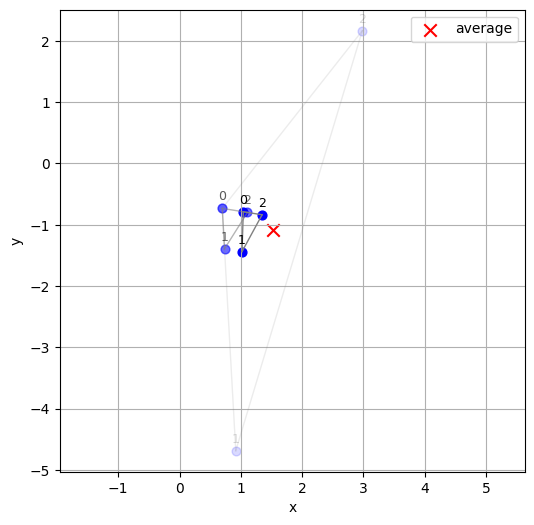

100%|██████████| 2/2 [00:00<00:00, 22733.36it/s]


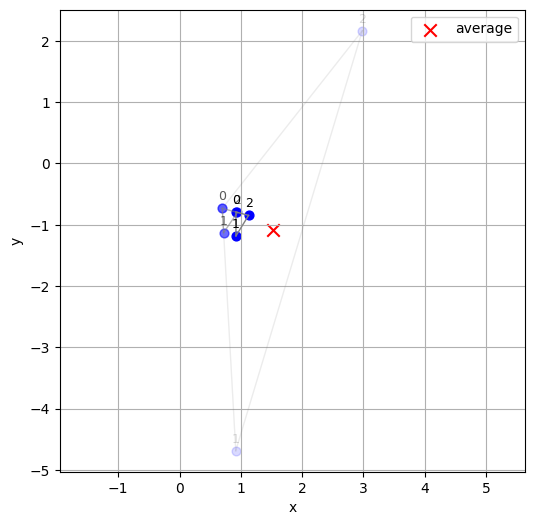

100%|██████████| 2/2 [00:00<00:00, 24105.20it/s]


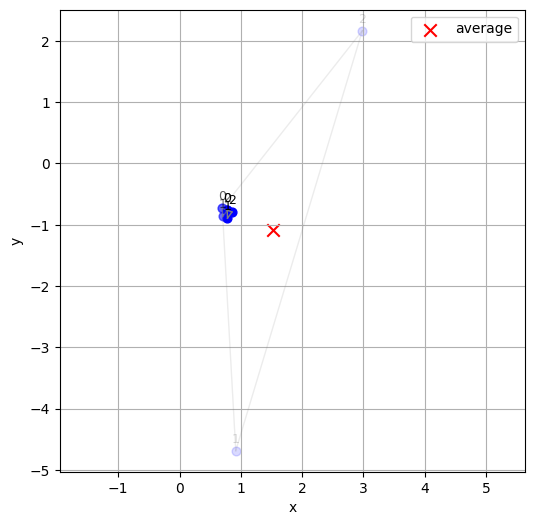

100%|██████████| 2/2 [00:00<00:00, 21290.88it/s]


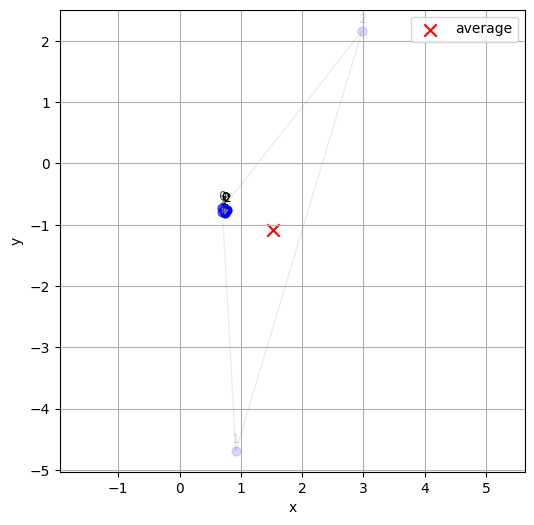

100%|██████████| 2/2 [00:00<00:00, 22250.95it/s]


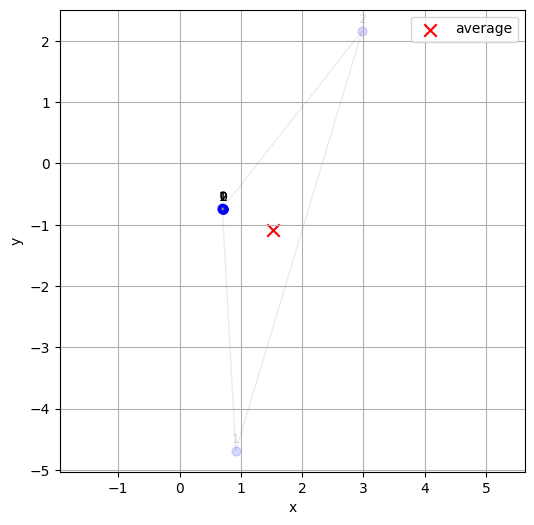

100%|██████████| 2/2 [00:00<00:00, 25575.02it/s]


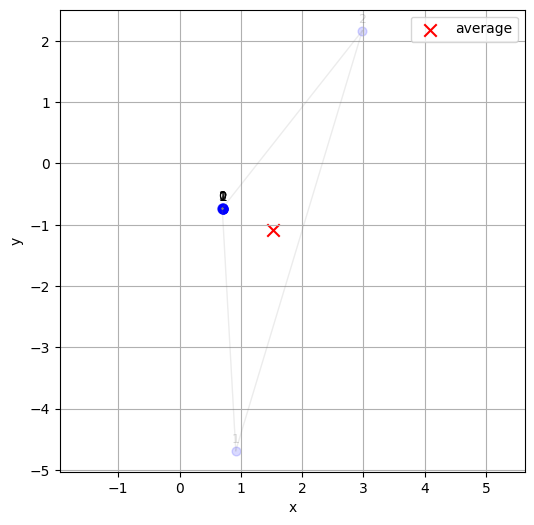

In [2]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from proxtoolbox.algorithms.metric import Prox
from proxtoolbox.spaces.euclidean import EuclideanSpace

space = EuclideanSpace(dimension=2, metric="euclidean")
S = space.sample(n_samples=3, seed=0, diam=10, dtype=np.float64)

prox = Prox(space=space)

taus = [0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
means = []
sequences = []
avg = space.average(S)
for t in taus:
    fm, x_seq = prox.Frechet_mean_EU(
        S[0], S,
        method="relaxed",
        tau=t,
        tol=1e-13,
        max_iter=2,
        show_progress=True,
        plot=True
    )
    means.append(fm)
    sequences.append(x_seq)


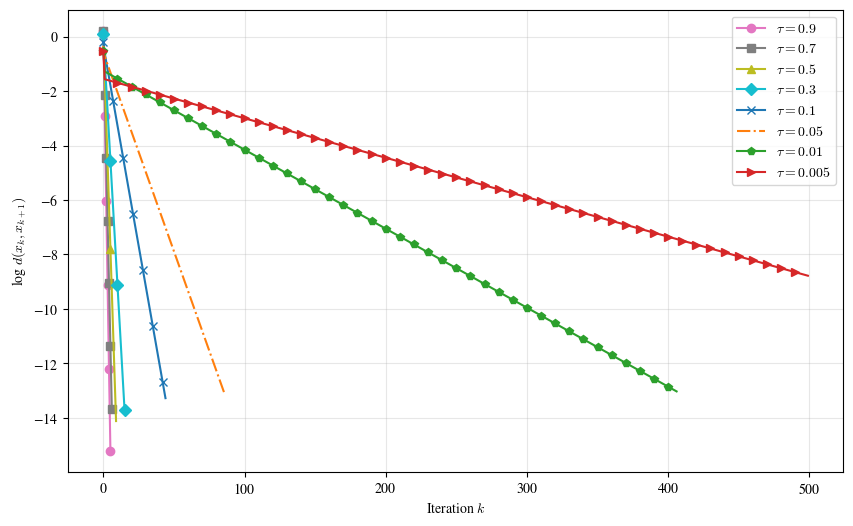

In [52]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['no-latex'])  # no-latex avoids LaTeX dependency



styles = ["-o", "-s", "-^", "-D", "-x", "-.", "-p", "->"]        
colors = [f"C{i+6}" for i in range(len(taus)+10)] 
#colors = plt.cm.Blues(np.linspace(0.9, 0.2, len(taus)))  # avoid too-white and too-dark 
freq = [1, 1, 5, 5, 7, 10, 10,10]
plt.figure(figsize=(10,6))       
for i in range(len(sequences)):
    outer_seq = [x[-1] for x in sequences[i]]
    distances = [np.log10(space.dist(outer_seq[j], outer_seq[j+1])) for j in range(len(outer_seq)-1)]
    plt.plot(distances, styles[i], color=colors[i], markevery=freq[i], label=rf'$\tau={taus[i]}$')


plt.xlabel(r'Iteration $k$')
plt.ylabel(r'log $d(x_{k} , x_{k+1})$')
#plt.title('Convergence of SPD iterates')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.show()
plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/SPD_iterates.png", 
bbox_inches="tight",
dpi=1000
)

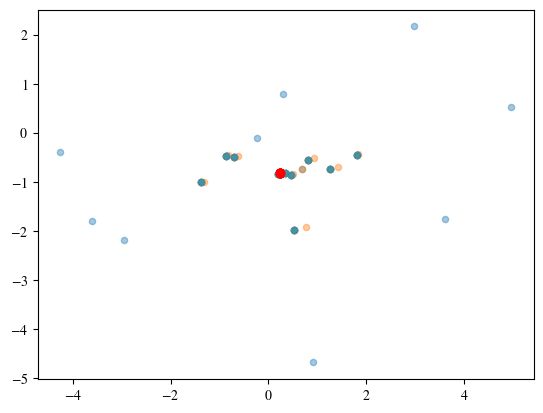

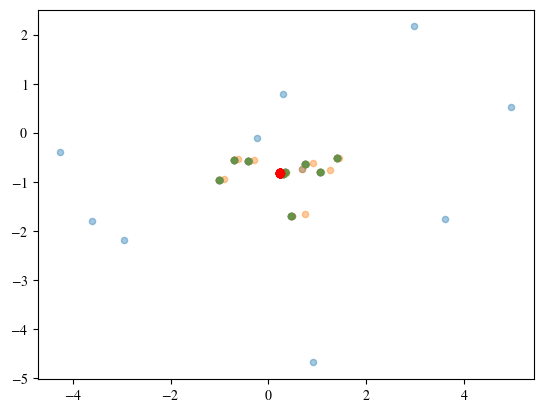

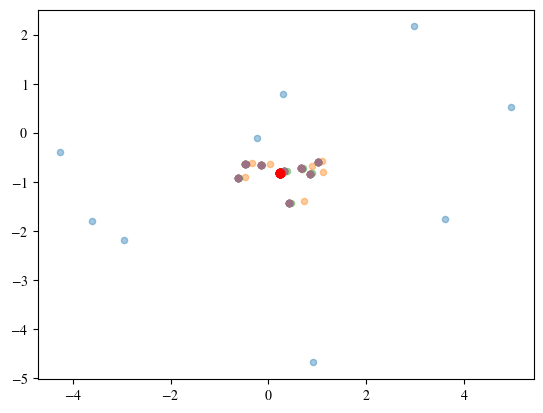

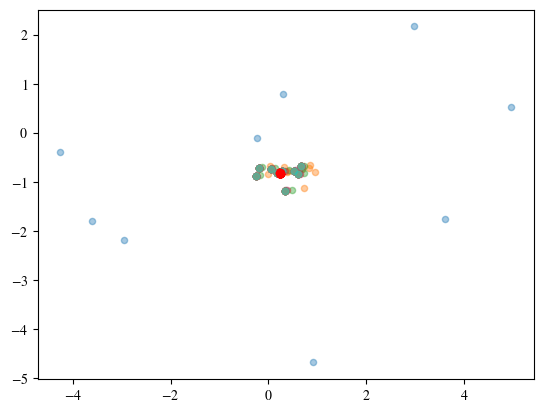

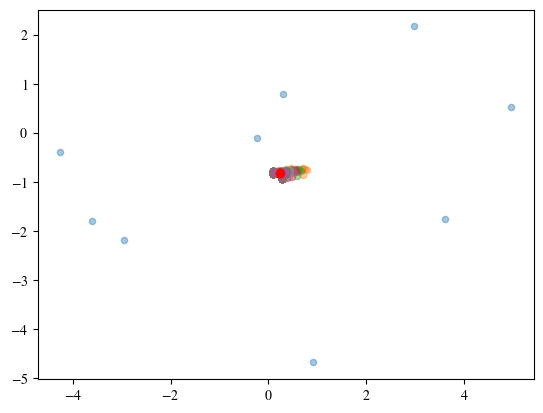

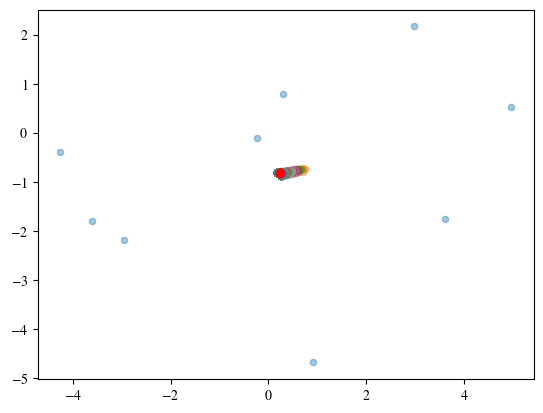

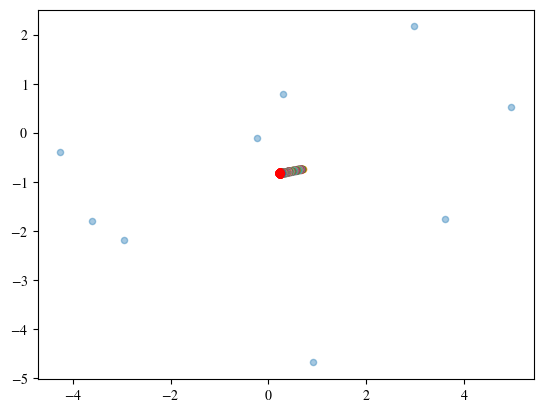

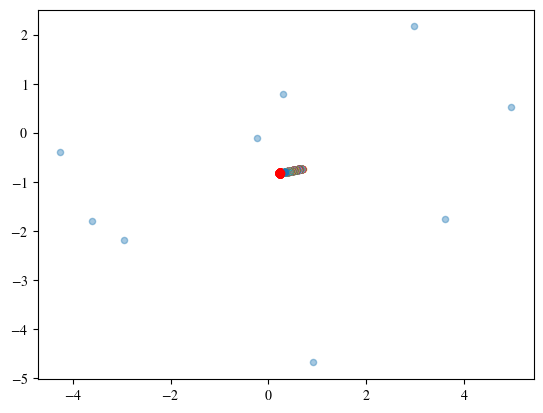

In [67]:
import numpy as np
import matplotlib.pyplot as plt
colors = [f"C{i}" for i in range(len(taus)+500)] 

for x_seq in sequences:
    i = 0
    for X in x_seq:
        x = [p[0] for p in X]
        y = [p[1] for p in X]
        plt.scatter(x, y, color=colors[i], s=20, alpha = 0.4)
        plt.scatter(avg[0], avg[1], color="red")
        i+= 1
    plt.show()

In [41]:
x_seq[0]

[array([ 0.69775287, -0.73312961]),
 array([ 0.91802531, -4.68786934]),
 array([2.98283822, 2.16640276]),
 array([-0.23472587, -0.11561258]),
 array([-4.25220775, -0.40014421]),
 array([-2.95289925, -2.19474749]),
 array([0.30901498, 0.78262476]),
 array([ 3.61664082, -1.76058143]),
 array([4.96620573, 0.51676793]),
 array([-3.6117281 , -1.79357243])]